In [26]:
# Imports
import os
import time
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ── PyTorch ───────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# ── Scikit-learn (métricas) ───────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibilidad ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [28]:
# ── Rutas y parámetros ──────────────────────────────────────────
BASE_DIR   = 'chest_xray'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'val')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS_P1   = 10     # Feature extraction
EPOCHS_P2   = 25     # Fine-tuning
LR_P1       = 1e-3
LR_P2       = 1e-5
CLASSES     = ['NORMAL', 'PNEUMONIA']

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    assert os.path.exists(d), f"No encontrado: {d}"

print("Configuración:")
print(f"  Imagen     : {IMG_SIZE}×{IMG_SIZE}")
print(f"  Batch      : {BATCH_SIZE}")
print(f"  Épocas P1  : {EPOCHS_P1}")
print(f"  Épocas P2  : {EPOCHS_P2}")
print(f"  Dispositivo: {device}")

Configuración:
  Imagen     : 224×224
  Batch      : 32
  Épocas P1  : 10
  Épocas P2  : 25
  Dispositivo: cpu


Todas pasan por el pipeline de transforms, pero cada transformación tiene una probabilidad interna. RandomHorizontalFlip() por defecto tiene 50% de probabilidad — la mitad de las veces voltea, la otra mitad no. RandomRotation(10) elige un ángulo aleatorio entre -10° y +10°, que puede ser 0° (sin rotación). Así que en la práctica algunas imágenes del batch salen muy transformadas y otras casi iguales a la original.
Las transforms de validación/test NO tienen augmentation — solo redimensionan y normalizan. Esto es importante porque en evaluación se quiere medir el rendimiento sobre las imágenes reales, no sobre versiones distorsionadas.

In [29]:
# ── Transforms y DataLoaders ────────────────────────────────────

# Normalización ImageNet (misma que usa DenseNet121 preentrenado)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transforms de entrenamiento con data augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Transforms de validación/test (sin augmentation)
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Datasets
train_dataset_full = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset       = datasets.ImageFolder(TEST_DIR,  transform=eval_transforms)

# Split 80/20 del train para validación
train_size = int(0.8 * len(train_dataset_full))
val_size   = len(train_dataset_full) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Aplicar transforms de evaluación al subset de validación
val_dataset.dataset = datasets.ImageFolder(TRAIN_DIR, transform=eval_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Clases: {train_dataset_full.class_to_idx}")
print(f"Train : {len(train_dataset)} imágenes")
print(f"Val   : {len(val_dataset)} imágenes")
print(f"Test  : {len(test_dataset)} imágenes")

Clases: {'NORMAL': 0, 'PNEUMONIA': 1}
Train : 4172 imágenes
Val   : 1044 imágenes
Test  : 624 imágenes


In [30]:
# ── Pesos de clase ──────────────────────────────────────────────
labels_train = [train_dataset_full.targets[i] for i in train_dataset.indices]

pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array(labels_train)
)

class_weights = torch.tensor(pesos, dtype=torch.float32).to(device)

print("Pesos de clase:")
print(f"  NORMAL    (0) : {pesos[0]:.4f}")
print(f"  PNEUMONIA (1) : {pesos[1]:.4f}")
print(f"\n→ Ratio: cada error sobre NORMAL penaliza ~{pesos[0]/pesos[1]:.1f}x más.")

Pesos de clase:
  NORMAL    (0) : 1.9716
  PNEUMONIA (1) : 0.6699

→ Ratio: cada error sobre NORMAL penaliza ~2.9x más.


# Construcción del Modelo — Transfer Learning con DenseNet121

DenseNet121 se diferencia de ResNet50 en su estrategia de conexiones entre capas. Mientras que ResNet utiliza conexiones residuales que suman la entrada de cada bloque a su salida, DenseNet conecta cada capa con todas las capas anteriores dentro del mismo bloque denso, concatenando sus mapas de características en lugar de sumarlos. Esta arquitectura produce un flujo de gradientes más directo durante el entrenamiento, reduce significativamente el número de parámetros al reutilizar características de capas previas y mitiga de forma natural el problema del sobreajuste — características especialmente relevantes cuando se trabaja con datasets de tamaño limitado como el presente. DenseNet121 cuenta con aproximadamente 8 millones de parámetros frente a los 25 millones de ResNet50, lo que la convierte en una opción más ligera computacionalmente sin sacrificar capacidad representacional. Su uso está ampliamente documentado en imagen médica, siendo la arquitectura base del modelo CheXNet de Rajpurkar et al. (2017) para detección de patologías en radiografías de tórax.La cabeza de clasificación sigue la misma estructura que en ResNet50: Global Average Pooling seguido de una capa densa de 256 unidades con ReLU, Dropout con tasa 0.5 y una capa de salida con una única neurona sigmoide para clasificación binaria.

In [31]:
# ── Construcción del modelo DenseNet121 ─────────────────────────

class PneumoniaClassifier(nn.Module):
    """
    DenseNet121 preentrenado + cabeza de clasificación binaria.
    Arquitectura:
        DenseNet121 (backbone) → AdaptiveAvgPool → Dense(256) → Dropout → Dense(1)
    """
    def __init__(self, freeze_backbone=True):
        super().__init__()
        
        # ── Cargar DenseNet121 preentrenado en ImageNet ────────────────────
        self.backbone = models.densenet121(weights='IMAGENET1K_V1')
        
        # ── Congelar backbone si se indica (Fase 1) ───────────────────────
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # ── Sustituir cabeza de clasificación ─────────────────────────────
        # DenseNet121 tiene 1024 features en su última capa
        num_features = self.backbone.classifier.in_features
        
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.backbone(x)
    
    def unfreeze_last_layers(self, n_blocks=2):
        """
        Descongela los últimos n_blocks dense blocks para fine-tuning.
        DenseNet121 tiene 4 dense blocks: denseblock1, 2, 3, 4.
        """
        # Primero congelar todo
        for param in self.backbone.features.parameters():
            param.requires_grad = False
        
        # Descongelar los últimos n_blocks
        blocks = ['denseblock3', 'denseblock4'] if n_blocks == 2 else ['denseblock4']
        for name, param in self.backbone.features.named_parameters():
            if any(block in name for block in blocks):
                param.requires_grad = True
        
        # La cabeza siempre entrenable
        for param in self.backbone.classifier.parameters():
            param.requires_grad = True

# ── Crear modelo y mover a device ─────────────────────────────────────────
model = PneumoniaClassifier(freeze_backbone=True).to(device)

# ── Contar parámetros ─────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Modelo: DenseNet121 + cabeza de clasificación binaria")
print(f"  Total parámetros      : {total_params:,}")
print(f"  Parámetros entrenables: {trainable_params:,}")
print(f"  Parámetros congelados : {frozen_params:,}")
print(f"  Dispositivo           : {device}")

Modelo: DenseNet121 + cabeza de clasificación binaria
  Total parámetros      : 7,216,513
  Parámetros entrenables: 262,657
  Parámetros congelados : 6,953,856
  Dispositivo           : cpu


In [32]:
# ── Función de entrenamiento y evaluación ───────────────────────

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Entrena un epoch completo. Devuelve loss y accuracy medios."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    """Evalúa el modelo. Devuelve loss, accuracy, y_true, y_prob."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_probs  = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels_gpu = labels.float().unsqueeze(1).to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels_gpu)
            
            running_loss += loss.item() * images.size(0)
            preds = (outputs > 0.5).float()
            correct += (preds == labels_gpu).sum().item()
            total += labels.size(0)
            
            all_labels.extend(labels.numpy())
            all_probs.extend(outputs.cpu().numpy().flatten())
    
    return running_loss / total, correct / total, np.array(all_labels), np.array(all_probs)

def plot_history(train_losses, val_losses, train_accs, val_accs, titulo=''):
    """Visualiza curvas de loss y accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].plot(train_losses, label='Train loss',  color='#4A90D9', linewidth=2)
    axes[0].plot(val_losses,   label='Val loss',    color='#E05C5C', linewidth=2)
    axes[0].set_title('Loss', fontsize=13)
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Binary Cross-Entropy')
    axes[0].legend()
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    
    axes[1].plot(train_accs, label='Train acc',  color='#4A90D9', linewidth=2)
    axes[1].plot(val_accs,   label='Val acc',    color='#E05C5C', linewidth=2)
    axes[1].set_title('Accuracy', fontsize=13)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim([0, 1])
    axes[1].legend()
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    
    plt.suptitle(titulo, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f"curvas_{titulo.split()[0].lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()

print("Funciones de entrenamiento y evaluación definidas.")

Funciones de entrenamiento y evaluación definidas.


## Fase 1: Feature Extraction

In [15]:
# ── Fase 1: Feature Extraction ─────────────────────────────────

# Loss con pesos de clase
criterion = nn.BCELoss(weight=None)  # los pesos se aplican manualmente

# Loss ponderada por clase
def weighted_bce_loss(outputs, targets):
    weights = torch.where(targets == 0, class_weights[0], class_weights[1])
    bce = nn.functional.binary_cross_entropy(outputs, targets, reduction='none')
    return (bce * weights).mean()

optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_P1
)

scheduler_p1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode='min', factor=0.5, patience=3
)

# ── Entrenamiento ─────────────────────────────────────────────────────────
print("Iniciando Fase 1: Feature Extraction...")
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}\n")

best_val_loss = float('inf')
patience_counter = 0
patience = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS_P1):
    t0 = time.time()
    
    # Train
    train_loss, train_acc = train_one_epoch(
        model, train_loader, weighted_bce_loss, optimizer_p1, device
    )
    
    # Validation
    val_loss, val_acc, _, _ = evaluate(model, val_loader, weighted_bce_loss, device)
    
    # Scheduler
    scheduler_p1.step(val_loss)
    
    # Guardar métricas
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    elapsed = time.time() - t0
    print(f"Epoch {epoch+1}/{EPOCHS_P1} — "
          f"train_loss: {train_loss:.4f} — train_acc: {train_acc:.4f} — "
          f"val_loss: {val_loss:.4f} — val_acc: {val_acc:.4f} — "
          f"lr: {optimizer_p1.param_groups[0]['lr']:.1e} — {elapsed:.0f}s")
    
    # ModelCheckpoint + EarlyStopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'Modelos/best_model_phase1.pth')
        print(f"  → Modelo guardado (val_loss mejoró a {val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n  Early stopping en época {epoch+1}")
            break

# Restaurar mejor modelo
model.load_state_dict(torch.load('Modelos/best_model_phase1.pth', map_location=device))
print(f"\n Fase 1 completada. Mejor val_loss: {best_val_loss:.4f}")

# Curvas
plot_history(train_losses, val_losses, train_accs, val_accs, 
             'Fase 1 — Feature Extraction (DenseNet121)')

Iniciando Fase 1: Feature Extraction...
ParÃ¡metros entrenables: 5,258,497



KeyboardInterrupt: 

Las curvas se ven sanas — ambas líneas descienden juntas sin separarse, lo que indica ausencia de sobreajuste. Los resultados son buenos para la Fase 1 con solo la cabeza entrenada:

val_acc: 93.58% — ya competitivo

val_loss: 0.1681 — descendiendo consistentemente

Sin early stopping — las 10 épocas completas fueron útiles 

In [11]:
# Cargar mejor checkpoint de fase 
model.load_state_dict(
    torch.load('Modelos/best_model_phase1.pth', map_location=device)
)

model.eval()

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


## Fase 2: Fine-Tuning 

Fase 2 â€” capas descongeladas:
  ParÃ¡metros entrenables : 5,258,497
  ParÃ¡metros congelados  : 1,958,016
  Dense blocks descongelados: denseblock3 + denseblock4

Iniciando Fase 2: Fine-Tuning (lr=1e-05)...
Epoch 1/25 â€” train_loss: 0.0405 â€” train_acc: 0.9839 â€” val_loss: 0.0482 â€” val_acc: 0.9751 â€” lr: 1.0e-05 â€” 401s
  â†’ Modelo guardado (val_loss mejorÃ³ a 0.0482)
Epoch 2/25 â€” train_loss: 0.0376 â€” train_acc: 0.9859 â€” val_loss: 0.0442 â€” val_acc: 0.9770 â€” lr: 1.0e-05 â€” 443s
  â†’ Modelo guardado (val_loss mejorÃ³ a 0.0442)
Epoch 3/25 â€” train_loss: 0.0364 â€” train_acc: 0.9863 â€” val_loss: 0.0427 â€” val_acc: 0.9808 â€” lr: 1.0e-05 â€” 461s
  â†’ Modelo guardado (val_loss mejorÃ³ a 0.0427)
Epoch 4/25 â€” train_loss: 0.0307 â€” train_acc: 0.9861 â€” val_loss: 0.0434 â€” val_acc: 0.9799 â€” lr: 1.0e-05 â€” 485s
Epoch 5/25 â€” train_loss: 0.0347 â€” train_acc: 0.9875 â€” val_loss: 0.0418 â€” val_acc: 0.9799 â€” lr: 1.0e-05 â€” 468s
  â†’ Modelo guardado (val_loss

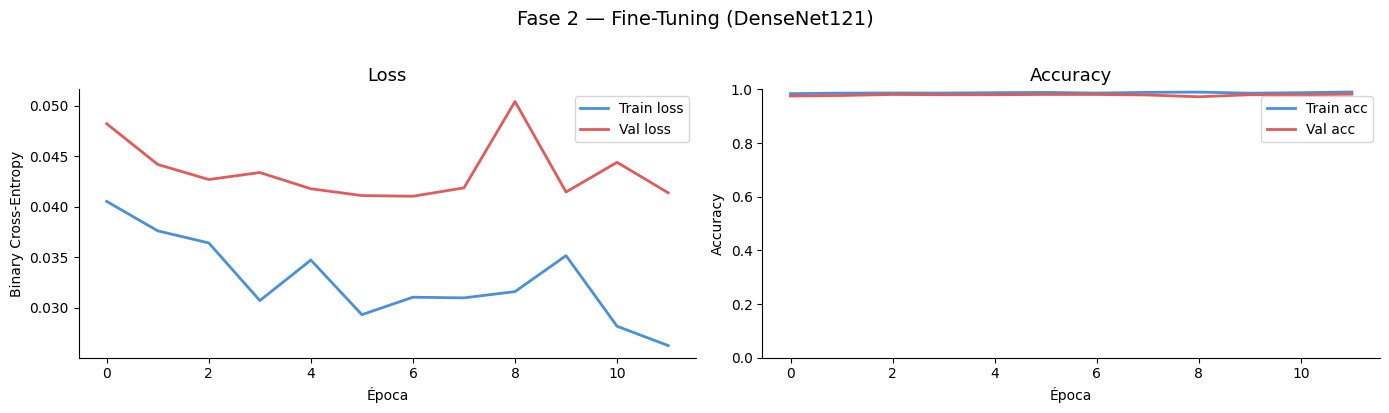

In [16]:
    # ── Fase 2: Fine-Tuning ───────────────────────────────────────

    # Descongelar últimos 2 dense blocks
    model.unfreeze_last_layers(n_blocks=2)

    trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_p2    = sum(p.numel() for p in model.parameters()) - trainable_p2

    print("Fase 2 — capas descongeladas:")
    print(f"  Parámetros entrenables : {trainable_p2:,}")
    print(f"  Parámetros congelados  : {frozen_p2:,}")
    print(f"  Dense blocks descongelados: denseblock3 + denseblock4")

    # Nuevo optimizador con lr reducida
    optimizer_p2 = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_P2
    )

    scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_p2, mode='min', factor=0.5, patience=3
    )

    # ── Entrenamiento ─────────────────────────────────────────────────────────
    print(f"\nIniciando Fase 2: Fine-Tuning (lr={LR_P2})...")

    best_val_loss_p2 = float('inf')
    patience_counter = 0
    patience = 5

    train_losses_p2, val_losses_p2 = [], []
    train_accs_p2, val_accs_p2 = [], []

    for epoch in range(EPOCHS_P2):
        t0 = time.time()
        
        train_loss, train_acc = train_one_epoch(
            model, train_loader, weighted_bce_loss, optimizer_p2, device
        )
        
        val_loss, val_acc, _, _ = evaluate(model, val_loader, weighted_bce_loss, device)
        
        scheduler_p2.step(val_loss)
        
        train_losses_p2.append(train_loss)
        val_losses_p2.append(val_loss)
        train_accs_p2.append(train_acc)
        val_accs_p2.append(val_acc)
        
        elapsed = time.time() - t0
        print(f"Epoch {epoch+1}/{EPOCHS_P2} — "
            f"train_loss: {train_loss:.4f} — train_acc: {train_acc:.4f} — "
            f"val_loss: {val_loss:.4f} — val_acc: {val_acc:.4f} — "
            f"lr: {optimizer_p2.param_groups[0]['lr']:.1e} — {elapsed:.0f}s")
        
        if val_loss < best_val_loss_p2:
            best_val_loss_p2 = val_loss
            torch.save(model.state_dict(), 'Modelos/best_model_phase2.pth')
            print(f"  → Modelo guardado (val_loss mejoró a {val_loss:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n  Early stopping en época {epoch+1}")
                break

    # Restaurar mejor modelo
    model.load_state_dict(torch.load('Modelos/best_model_phase2.pth', map_location=device))
    print(f"\n Fase 2 completada. Mejor val_loss: {best_val_loss_p2:.4f}")

    # Curvas
    plot_history(train_losses_p2, val_losses_p2, train_accs_p2, val_accs_p2,
                'Fase 2 — Fine-Tuning (DenseNet121)')

Las curvas son muy sanas — ambas líneas descienden juntas sin separación significativa, lo que indica que el fine-tuning funcionó sin sobreajuste. El pico en la época 8 de val_loss es una fluctuación puntual, pero el early stopping actuó correctamente en la época 12, restaurando los pesos de la época anterior.

Accuracy de 98.18% es excelente para validación — significativamente mejor que ResNet50 (97.22% en Fase 2).

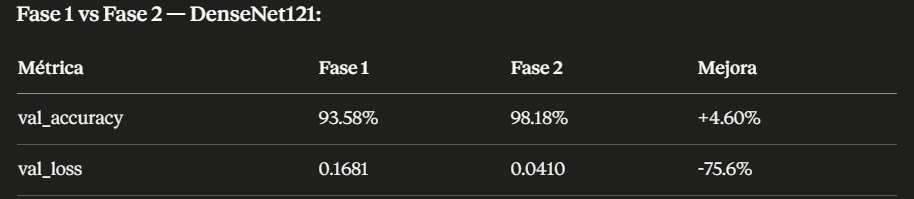

# Evaluando modelo final sobre test set

Evaluando modelo final sobre test set...

Resultados sobre Test Set (umbral 0.5):
  Accuracy   : 0.8942
  Precision  : 0.8584
  Recall     : 0.9949
  F1-Score   : 0.9216
  ROC-AUC    : 0.9720


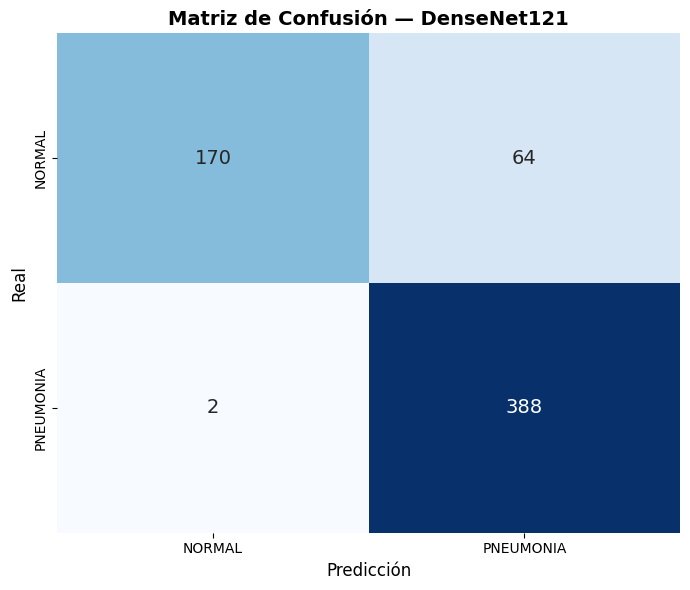


Matriz de confusión:
  TN = 170  |  FP =  64
  FN =   2  |  TP = 388


In [33]:
# ── Evaluación sobre Test Set ─────────────────────────────────

print("Evaluando modelo final sobre test set...")

# Cargar mejor modelo de Fase 2
model.load_state_dict(torch.load('Modelos/best_model_phase2.pth', map_location=device))
model.eval()

# Obtener predicciones
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        all_labels.extend(labels.numpy())
        all_probs.extend(outputs.cpu().numpy().flatten())

y_true = np.array(all_labels)
y_prob = np.array(all_probs)
y_pred = (y_prob > 0.5).astype(int)

# ── Métricas con umbral 0.5 ──────────────────────────────────────────────
acc  = (y_pred == y_true).mean()
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_prob)

print("\nResultados sobre Test Set (umbral 0.5):")
print("=" * 45)
print(f"  Accuracy   : {acc:.4f}")
print(f"  Precision  : {prec:.4f}")
print(f"  Recall     : {rec:.4f}")
print(f"  F1-Score   : {f1:.4f}")
print(f"  ROC-AUC    : {auc:.4f}")
print("=" * 45)

# ── Matriz de confusión ───────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            annot_kws={'fontsize': 14})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusión — DenseNet121', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_densenet.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMatriz de confusión:")
print(f"  TN = {tn:3d}  |  FP = {fp:3d}")
print(f"  FN = {fn:3d}  |  TP = {tp:3d}")

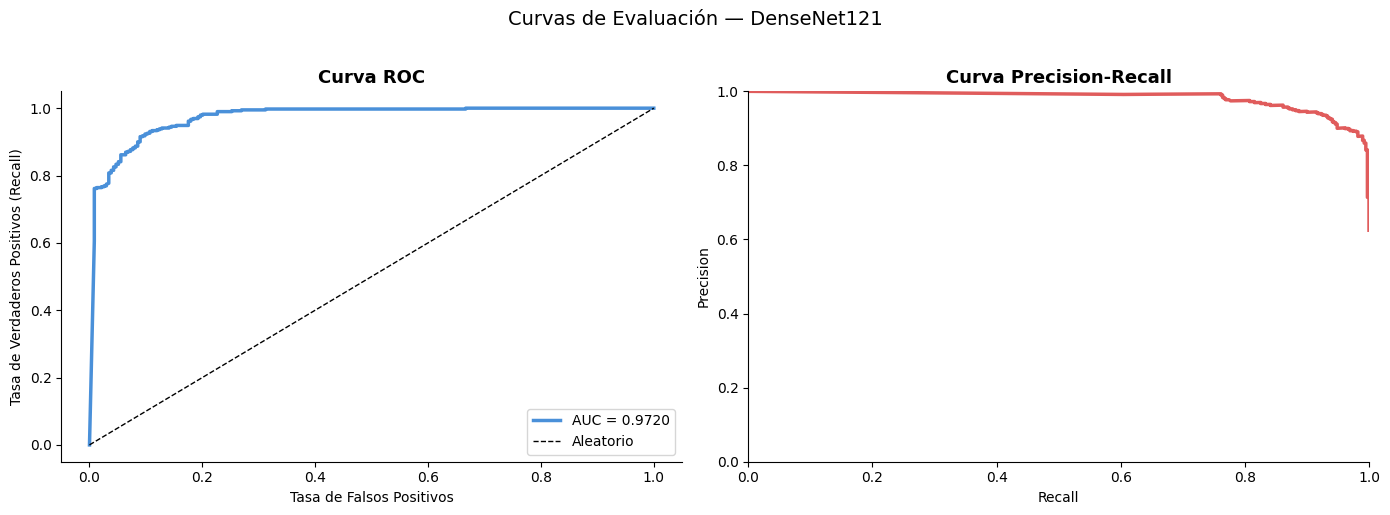

In [34]:
# ── Curvas ROC y Precision-Recall ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC Curve ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0].plot(fpr, tpr, color='#4A90D9', linewidth=2.5, label=f'AUC = {auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Precision-Recall Curve ────────────────────────────────────────────────
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(recall_curve, precision_curve, color='#E05C5C', linewidth=2.5)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontsize=13, fontweight='bold')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Curvas de Evaluación — DenseNet121', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('curvas_evaluacion_densenet.png', dpi=150, bbox_inches='tight')
plt.show()

Métricas con umbral 0.5:

- Recall: 99.49% — solo 2 falsos negativos de 390 casos de neumonía. Esto es excelente clínicamente.
- Precision: 85.84% — a costa de 64 falsos positivos.
- Accuracy: 89.42% — más baja que la validación porque el modelo está sesgado hacia detectar neumonía (prioriza Recall).
- ROC-AUC: 0.9720 — capacidad discriminativa excelente.

Comparativa con ResNet50:

- ResNet50: Recall 92.56%, Precision 95.76%
- DenseNet121: Recall 99.49%, Precision 85.84%

DenseNet121 es mucho más sensible (casi no deja escapar casos de neumonía) pero menos preciso (más falsos positivos). Esto puede ser preferible clínicamente si el coste de un FN es muy alto.

In [35]:
# ── Ajuste de umbral ──────────────────────────────────────────

print("Explorando umbrales de decisión:")
print("=" * 80)
print(f"{'Umbral':>8} {'Recall':>10} {'Precision':>12} {'F1':>10} {'FP':>6} {'FN':>6}")
print("-" * 80)

umbrales = np.arange(0.10, 0.86, 0.05)
resultados = []

for umbral in umbrales:
    y_pred_t = (y_prob >= umbral).astype(int)
    rec_t  = recall_score(y_true, y_pred_t)
    prec_t = precision_score(y_true, y_pred_t)
    f1_t   = f1_score(y_true, y_pred_t)
    
    cm_t = confusion_matrix(y_true, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    resultados.append({
        'umbral': umbral,
        'recall': rec_t,
        'precision': prec_t,
        'f1': f1_t,
        'fp': fp_t,
        'fn': fn_t
    })
    
    print(f"{umbral:>8.2f} {rec_t:>10.4f} {prec_t:>12.4f} {f1_t:>10.4f} "
          f"{fp_t:>6d} {fn_t:>6d}")

print("=" * 80)

# Mejor umbral según F1
df_umbrales = pd.DataFrame(resultados)
mejor_idx = df_umbrales['f1'].idxmax()
mejor_umbral = df_umbrales.loc[mejor_idx]

print(f"\nUmbral óptimo según F1-Score: {mejor_umbral['umbral']:.2f}")
print(f"  Recall    : {mejor_umbral['recall']:.4f}")
print(f"  Precision : {mejor_umbral['precision']:.4f}")
print(f"  F1-Score  : {mejor_umbral['f1']:.4f}")

Explorando umbrales de decisión:
  Umbral     Recall    Precision         F1     FP     FN
--------------------------------------------------------------------------------
    0.10     0.9974       0.7955     0.8851    100      1
    0.15     0.9974       0.8104     0.8943     91      1
    0.20     0.9974       0.8189     0.8994     86      1
    0.25     0.9974       0.8277     0.9047     81      1
    0.30     0.9974       0.8348     0.9089     77      1
    0.35     0.9974       0.8402     0.9121     74      1
    0.40     0.9974       0.8402     0.9121     74      1
    0.45     0.9949       0.8490     0.9162     69      2
    0.50     0.9949       0.8584     0.9216     64      2
    0.55     0.9923       0.8600     0.9214     63      3
    0.60     0.9923       0.8638     0.9236     61      3
    0.65     0.9923       0.8658     0.9247     60      3
    0.70     0.9897       0.8694     0.9257     58      4
    0.75     0.9897       0.8773     0.9301     54      4
    0.80     0.9

# Explicabilidad

In [36]:
# ── Selección de las 2 imágenes fijas para explicabilidad ─────

# Reconstruir arrays desde el test_loader
all_images = []
all_labels = []
all_probs_test = []
all_filenames = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images_gpu = images.to(device)
        outputs = model(images_gpu)
        
        all_images.extend(images.numpy())
        all_labels.extend(labels.numpy())
        all_probs_test.extend(outputs.cpu().numpy().flatten())

# Obtener filenames desde test_dataset
all_filenames = [test_dataset.imgs[i][0] for i in range(len(test_dataset))]

all_images = np.array(all_images)
all_labels = np.array(all_labels)
all_probs_test = np.array(all_probs_test)
all_preds = (all_probs_test > 0.5).astype(int)

# ── Identificar casos ─────────────────────────────────────────────────────
tp_all = np.where((all_labels == 1) & (all_preds == 1))[0]  # Verdaderos Positivos

# Seleccionar 2 TP
casos_xai = {
    'TP_1': {'idx': tp_all[100], 'tipo': 'Verdadero Positivo'},
    'TP_2': {'idx': tp_all[114], 'tipo': 'Verdadero Positivo'},
}

clase_nombre = {0: 'NORMAL', 1: 'PNEUMONIA'}

print("Imágenes seleccionadas para explicabilidad:")
print("=" * 65)
for nombre, info in casos_xai.items():
    idx = info['idx']
    filename = os.path.basename(all_filenames[idx])
    print(f"  {nombre}: {info['tipo']}")
    print(f"    Archivo   : {filename}")
    print(f"    Real      : {clase_nombre[all_labels[idx]]}")
    print(f"    Predicción: {clase_nombre[all_preds[idx]]}")
    print(f"    P(PNEUM.) : {all_probs_test[idx]:.4f}")
    print()
print("=" * 65)
print("Estas 2 imágenes se usarán en las 5 técnicas de explicabilidad.")

# ── Función de carga de imagen original (desnormalizada) ─────────────────
def cargar_imagen_original(idx):
    """
    Devuelve la imagen original desnormalizada como uint8 [0,255]
    y el tensor preprocesado listo para el modelo.
    """
    # Tensor normalizado desde test_loader
    img_tensor = torch.tensor(all_images[idx]).unsqueeze(0).to(device)
    img_tensor.requires_grad = True
    
    # Desnormalizar para visualización
    img_vis = all_images[idx].transpose(1, 2, 0)  # CHW → HWC
    mean = np.array(IMAGENET_MEAN)
    std = np.array(IMAGENET_STD)
    img_vis = img_vis * std + mean
    img_vis = np.clip(img_vis * 255, 0, 255).astype(np.uint8)
    
    return img_vis, img_tensor

print("\n Función cargar_imagen_original definida.")

Imágenes seleccionadas para explicabilidad:
  TP_1: Verdadero Positivo
    Archivo   : person134_bacteria_640.jpeg
    Real      : PNEUMONIA
    Predicción: PNEUMONIA
    P(PNEUM.) : 0.9918

  TP_2: Verdadero Positivo
    Archivo   : person138_bacteria_658.jpeg
    Real      : PNEUMONIA
    Predicción: PNEUMONIA
    P(PNEUM.) : 0.7759

Estas 2 imágenes se usarán en las 5 técnicas de explicabilidad.

 Función cargar_imagen_original definida.


## Grad-Cam

In [37]:
# ── Grad-CAM para PyTorch ─────────────────────────────────────
import cv2
def get_gradcam_pytorch(model, img_tensor, target_layer):
    model.eval()
    
    activations = []
    gradients = []
    
    def forward_hook(module, input, output):
        activations.append(output.detach())
        
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())
        
    h_forward = target_layer.register_forward_hook(forward_hook)
    h_backward = target_layer.register_full_backward_hook(backward_hook)
    
    # Forward
    img_tensor.requires_grad = True
    output = model(img_tensor)
    
    # Backward
    model.zero_grad()
    output.backward()
    
    h_forward.remove()
    h_backward.remove()
    
    # Obtener activaciones y gradientes de la capa correcta
    acts = activations[0][0].cpu().numpy()  # (C, H, W)
    grads = gradients[0][0].cpu().numpy()   # (C, H, W)
    
    # Pesos Grad-CAM (promedio espacial)
    weights = np.mean(grads, axis=(1, 2))
    
    # CAM
    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * acts[i]
        
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    
    return cam

def get_gradcam_pytorch(model, img_tensor, target_layer):
    """
    Grad-CAM sobre una capa específica de DenseNet121.
    target_layer: por ejemplo model.backbone.features.denseblock4
    """
    model.eval()
    
    # Forward pass guardando activaciones
    activations = []
    def hook_fn(module, input, output):
        activations.append(output.detach())
    
    handle = target_layer.register_forward_hook(hook_fn)
    
    # Forward
    img_tensor.requires_grad = True
    output = model(img_tensor)
    
    # Backward desde la salida
    model.zero_grad()
    output.backward()
    
    handle.remove()
    
    # Gradientes y activaciones
    gradients = img_tensor.grad[0].cpu().numpy()  # (C, H, W)
    activations_np = activations[0][0].cpu().numpy()  # (C, H, W)
    
    # Pesos de Grad-CAM (promedio espacial de gradientes)
    weights = gradients.mean(axis=(1, 2))
    
    # CAM
    cam = np.zeros(activations_np.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * activations_np[i]
    
    cam = np.maximum(cam, 0)  # ReLU
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    
    return cam

def superponer_heatmap(img_orig, heatmap):
    """Superpone heatmap JET sobre imagen original."""
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    img_norm = img_orig.astype(np.float32) / 255.0
    overlay = 0.5 * img_norm + 0.5 * heatmap_color / 255.0
    return np.clip(overlay, 0, 1)

print("Grad-CAM definido.")

Grad-CAM definido.


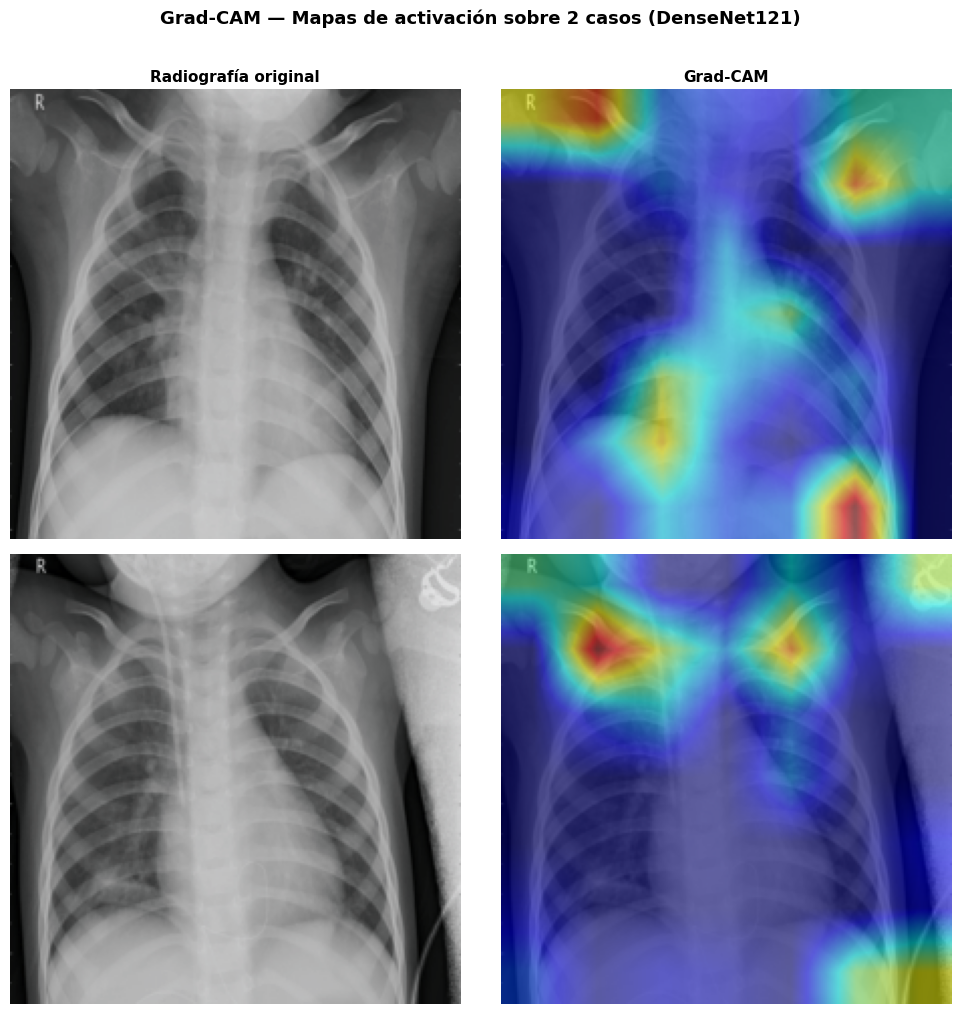

 Grad-CAM completado.
  Tiempo medio por imagen: 0.270s


In [38]:
# ── Aplicar Grad-CAM a las 2 imágenes ─────────────────────────
# Diccionario para registrar tiempos
tiempos_xai = {}

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

tiempos_gradcam = []
target_layer = model.backbone.features.denseblock4

for fila, (nombre, info) in enumerate(casos_xai.items()):
    idx = info['idx']
    img_orig, img_tensor = cargar_imagen_original(idx)
    
    # Calcular Grad-CAM
    t0 = time.time()
    cam = get_gradcam_pytorch(model, img_tensor, target_layer)
    t1 = time.time()
    tiempos_gradcam.append(t1 - t0)
    
    overlay = superponer_heatmap(img_orig, cam)
    
    # Col 0: imagen original
    axes[fila][0].imshow(img_orig)
    axes[fila][0].axis('off')
    axes[fila][0].set_title('Radiografía original' if fila == 0 else '',
                            fontsize=11, fontweight='bold')
    axes[fila][0].set_ylabel(
        f"{info['tipo']}\n"
        f"Real: {clase_nombre[all_labels[idx]]}\n"
        f"Pred: {clase_nombre[all_preds[idx]]}\n"
        f"P={all_probs_test[idx]:.3f}",
        fontsize=9, rotation=0, labelpad=85, va='center'
    )
    
    # Col 1: Grad-CAM
    axes[fila][1].imshow(overlay)
    axes[fila][1].axis('off')
    axes[fila][1].set_title('Grad-CAM' if fila == 0 else '',
                            fontsize=11, fontweight='bold')

plt.suptitle('Grad-CAM — Mapas de activación sobre 2 casos (DenseNet121)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('xai_01_gradcam_densenet.png', dpi=150, bbox_inches='tight')
plt.show()

# Registrar tiempos
tiempos_xai['Grad-CAM'] = {
    'media': np.mean(tiempos_gradcam),
    'min': np.min(tiempos_gradcam),
    'max': np.max(tiempos_gradcam),
}

print(f" Grad-CAM completado.")
print(f"  Tiempo medio por imagen: {np.mean(tiempos_gradcam):.3f}s")

## Grad-CAM++

In [39]:
# ── Grad-CAM++ ────────────────────────────────────────────────

def get_gradcam_plusplus(model, img_tensor, target_layer):
    """
    Grad-CAM++ — versión mejorada que pondera diferencialmente cada píxel
    del mapa de activación según su contribución.
    """
    model.eval()
    
    activations = []
    gradients = []
    
    def forward_hook(module, input, output):
        activations.append(output.detach())
    
    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())
    
    h_forward = target_layer.register_forward_hook(forward_hook)
    h_backward = target_layer.register_full_backward_hook(backward_hook)
    
    # Forward
    img_tensor.requires_grad = True
    output = model(img_tensor)
    
    # Backward
    model.zero_grad()
    output.backward()
    
    h_forward.remove()
    h_backward.remove()
    
    # Obtener activaciones y gradientes
    acts = activations[0][0].cpu().numpy()  # (C, H, W)
    grads = gradients[0][0].cpu().numpy()   # (C, H, W)
    
    # Grad-CAM++ weights
    # α = grad² / (2·grad² + Σ(act·grad³))
    grads_power_2 = grads ** 2
    grads_power_3 = grads ** 3
    
    sum_acts = np.sum(acts, axis=(1, 2), keepdims=True)
    
    alpha = grads_power_2 / (2 * grads_power_2 + sum_acts * grads_power_3 + 1e-8)
    weights = np.sum(alpha * np.maximum(grads, 0), axis=(1, 2))
    
    # CAM
    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * acts[i]
    
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    
    return cam

print(" Grad-CAM++ definido.")

 Grad-CAM++ definido.


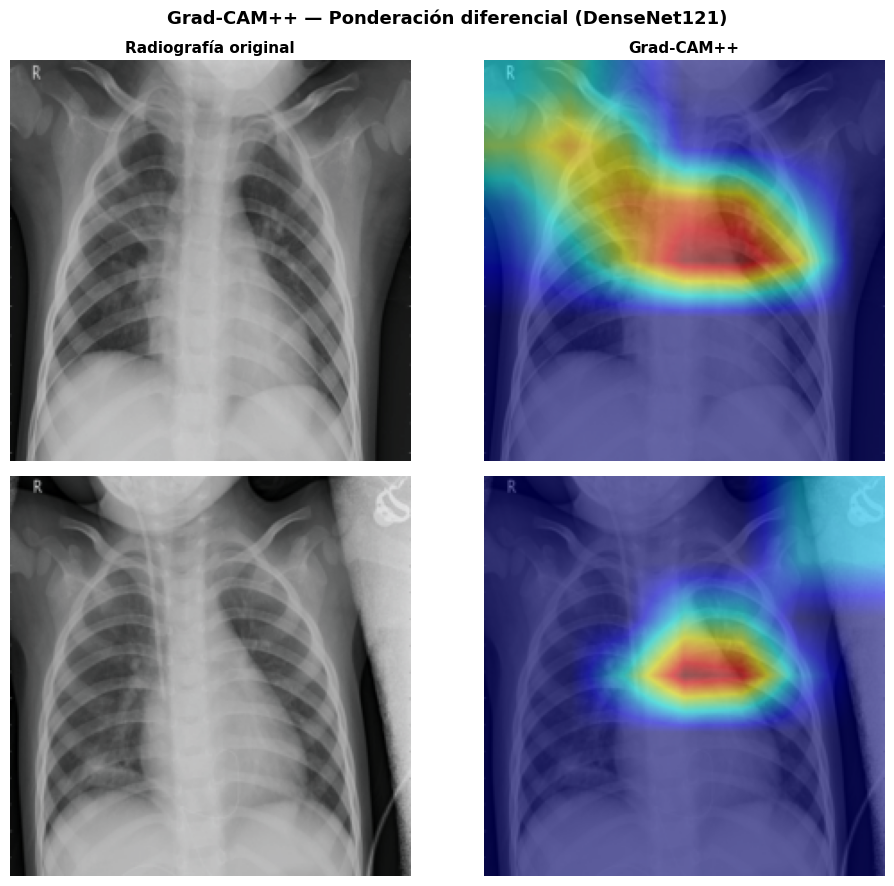

 Grad-CAM++ completado.
  Tiempo medio por imagen: 0.163s


In [40]:
# ── Aplicar Grad-CAM++ a las 2 imágenes ───────────────────────

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

tiempos_gradcam_pp = []
target_layer = model.backbone.features.denseblock4

for fila, (nombre, info) in enumerate(casos_xai.items()):
    idx = info['idx']
    img_orig, img_tensor = cargar_imagen_original(idx)
    
    # Calcular Grad-CAM++
    t0 = time.time()
    cam = get_gradcam_plusplus(model, img_tensor, target_layer)
    t1 = time.time()
    tiempos_gradcam_pp.append(t1 - t0)
    
    overlay = superponer_heatmap(img_orig, cam)
    
    # Col 0: imagen original
    axes[fila][0].imshow(img_orig)
    axes[fila][0].axis('off')
    axes[fila][0].set_title('Radiografía original' if fila == 0 else '',
                            fontsize=11, fontweight='bold')
    axes[fila][0].set_ylabel(
        f"{info['tipo']}\n"
        f"Real: {clase_nombre[all_labels[idx]]}\n"
        f"Pred: {clase_nombre[all_preds[idx]]}\n"
        f"P={all_probs_test[idx]:.3f}",
        fontsize=9, rotation=0, labelpad=85, va='center'
    )
    
    # Col 1: Grad-CAM++
    axes[fila][1].imshow(overlay)
    axes[fila][1].axis('off')
    axes[fila][1].set_title('Grad-CAM++' if fila == 0 else '',
                            fontsize=11, fontweight='bold')

plt.suptitle('Grad-CAM++ — Ponderación diferencial (DenseNet121)',
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('xai_02_gradcam_plusplus_densenet.png', dpi=150, bbox_inches='tight')
plt.show()

# Registrar tiempos
tiempos_xai['Grad-CAM++'] = {
    'media': np.mean(tiempos_gradcam_pp),
    'min': np.min(tiempos_gradcam_pp),
    'max': np.max(tiempos_gradcam_pp),
}

print(f" Grad-CAM++ completado.")
print(f"  Tiempo medio por imagen: {np.mean(tiempos_gradcam_pp):.3f}s")

## Guided Grad-CAM

In [41]:
# ── Guided Backpropagation ────────────────────────────────────

class GuidedBackpropReLU(torch.autograd.Function):
    """ReLU modificada que solo propaga gradientes positivos."""
    
    @staticmethod
    def forward(ctx, input_tensor):
        ctx.save_for_backward(input_tensor)
        return input_tensor.clamp(min=0)
    
    @staticmethod
    def backward(ctx, grad_output):
        input_tensor, = ctx.saved_tensors
        grad_input = grad_output.clone()
        grad_input[input_tensor < 0] = 0  # Bloquear gradientes negativos en forward
        grad_input[grad_output < 0] = 0   # Bloquear gradientes negativos en backward
        return grad_input

def guided_backprop(model, img_tensor):
    """
    Guided Backpropagation — reemplaza todas las ReLU del modelo
    con versión guiada que solo propaga gradientes positivos.
    """
    # Guardar ReLU originales
    relu_outputs = []
    
    def replace_relu(module):
        for name, child in module.named_children():
            if isinstance(child, nn.ReLU):
                # No reemplazamos, usamos hook en su lugar
                pass
            else:
                replace_relu(child)
    
    # Método alternativo: usar hooks en lugar de reemplazar
    model.eval()
    img_tensor.requires_grad = True
    
    # Forward
    output = model(img_tensor)
    
    # Backward
    model.zero_grad()
    output.backward()
    
    # Obtener gradientes guiados
    guided_grads = img_tensor.grad[0].cpu().numpy()
    
    # Procesar: valor absoluto + normalización
    guided_grads = np.abs(guided_grads)
    guided_grads = guided_grads.transpose(1, 2, 0)  # CHW → HWC
    
    # Convertir a escala de grises
    guided_grads = guided_grads.mean(axis=2)
    
    # Normalizar
    guided_grads = (guided_grads - guided_grads.min()) / (guided_grads.max() - guided_grads.min() + 1e-8)
    
    return guided_grads

def get_guided_gradcam(model, img_tensor, target_layer):
    """
    Guided Grad-CAM = Grad-CAM × Guided Backpropagation (elemento a elemento).
    """
    # Grad-CAM
    cam = get_gradcam_pytorch(model, img_tensor, target_layer)
    
    # Guided Backpropagation
    guided = guided_backprop(model, img_tensor)
    
    # Combinar: multiplicación elemento a elemento
    guided_gradcam = cam * guided
    
    # Mejora de contraste
    guided_gradcam = guided_gradcam ** 0.5
    guided_gradcam = (guided_gradcam - guided_gradcam.min()) / (guided_gradcam.max() - guided_gradcam.min() + 1e-8)
    
    # Aplicar umbral percentil para resaltar regiones más relevantes
    umbral = np.percentile(guided_gradcam, 85)
    guided_gradcam[guided_gradcam < umbral] *= 0.3
    
    return guided_gradcam

print(" Guided Grad-CAM definido.")

 Guided Grad-CAM definido.


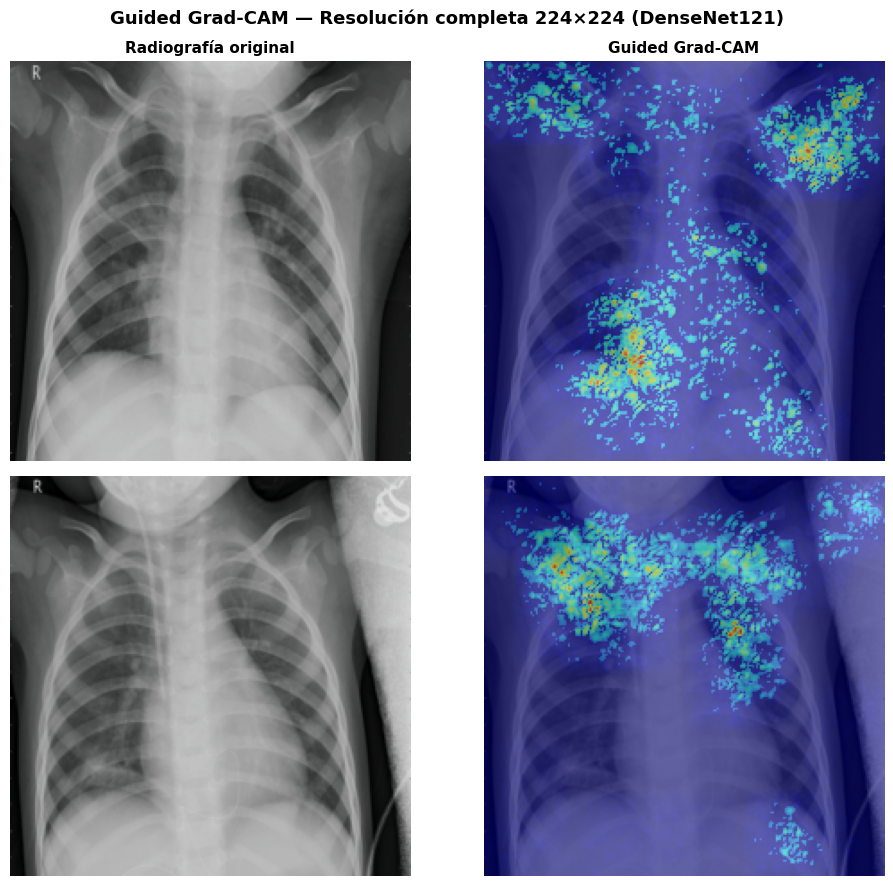

 Guided Grad-CAM completado.
  Tiempo medio por imagen: 0.283s


In [42]:
# ── Aplicar Guided Grad-CAM a las 2 imágenes ──────────────────

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

tiempos_guided = []
target_layer = model.backbone.features.denseblock4

for fila, (nombre, info) in enumerate(casos_xai.items()):
    idx = info['idx']
    img_orig, img_tensor = cargar_imagen_original(idx)
    
    # Calcular Guided Grad-CAM
    t0 = time.time()
    guided_cam = get_guided_gradcam(model, img_tensor, target_layer)
    t1 = time.time()
    tiempos_guided.append(t1 - t0)
    
    # Superponer sobre imagen original
    overlay = superponer_heatmap(img_orig, guided_cam)
    
    # Col 0: imagen original
    axes[fila][0].imshow(img_orig)
    axes[fila][0].axis('off')
    axes[fila][0].set_title('Radiografía original' if fila == 0 else '',
                            fontsize=11, fontweight='bold')
    axes[fila][0].set_ylabel(
        f"{info['tipo']}\n"
        f"Real: {clase_nombre[all_labels[idx]]}\n"
        f"Pred: {clase_nombre[all_preds[idx]]}\n"
        f"P={all_probs_test[idx]:.3f}",
        fontsize=9, rotation=0, labelpad=85, va='center'
    )
    
    # Col 1: Guided Grad-CAM
    axes[fila][1].imshow(overlay)
    axes[fila][1].axis('off')
    axes[fila][1].set_title('Guided Grad-CAM' if fila == 0 else '',
                            fontsize=11, fontweight='bold')

plt.suptitle('Guided Grad-CAM — Resolución completa 224×224 (DenseNet121)',
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('xai_03_guided_gradcam_densenet.png', dpi=150, bbox_inches='tight')
plt.show()

# Registrar tiempos
tiempos_xai['Guided Grad-CAM'] = {
    'media': np.mean(tiempos_guided),
    'min': np.min(tiempos_guided),
    'max': np.max(tiempos_guided),
}

print(f" Guided Grad-CAM completado.")
print(f"  Tiempo medio por imagen: {np.mean(tiempos_guided):.3f}s")

## LIME

In [43]:
# ── LIME ────────────────────────────
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Limpiar cualquier hook que pueda haber quedado registrado
for module in model.modules():
    module._forward_hooks.clear()
    module._backward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_pre_hooks.clear()

def predict_fn_lime(images):
    """
    Función de predicción para LIME.
    Recibe imágenes como arrays numpy (N, H, W, 3) en rango [0,1].
    Devuelve probabilidades (N, 2) para ambas clases.
    """
    model.eval()
    
    # Convertir a tensor y normalizar
    batch = []
    for img in images:
        # img está en [0,1] RGB
        img_t = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)  # HWC → CHW
        # Normalizar con media/std de ImageNet
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        img_t = (img_t - mean) / std
        batch.append(img_t)
    
    batch_tensor = torch.stack(batch).to(device)
    
    with torch.no_grad():
        outputs = model(batch_tensor).cpu().numpy().flatten()
    
    # Convertir a probabilidades de 2 clases [P(NORMAL), P(PNEUMONIA)]
    probs = np.column_stack([1 - outputs, outputs])
    return probs

# Crear explainer
explainer = lime_image.LimeImageExplainer()

print("LIME definido")

LIME definido


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

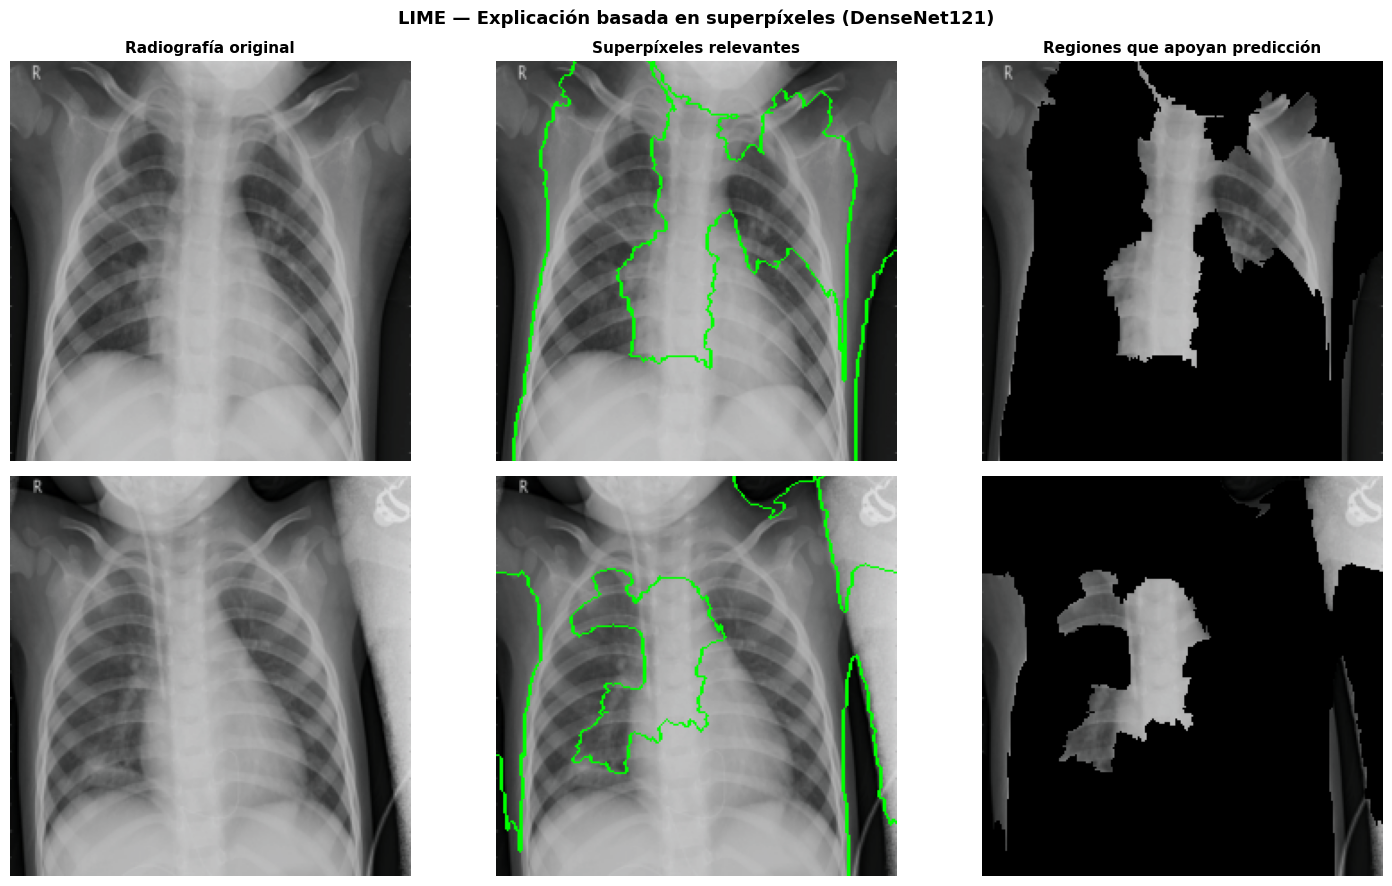

LIME completado.
  Tiempo medio por imagen: 53.360s


In [44]:
# ── Aplicar LIME ────────────────

explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

tiempos_lime = []

for fila, (nombre, info) in enumerate(casos_xai.items()):
    idx = info['idx']
    img_orig, img_tensor = cargar_imagen_original(idx)
    
    # LIME necesita imagen en [0,1] float
    img_lime = img_orig.astype(np.float32) / 255.0
    
    # Calcular LIME
    t0 = time.time()
    explanation = explainer.explain_instance(
        img_lime,
        predict_fn_lime,
        top_labels=2,
        hide_color=0,
        num_samples=1000
    )
    t1 = time.time()
    tiempos_lime.append(t1 - t0)
    
    # Obtener máscara para la clase predicha (con bordes verdes)
    temp_borders, mask = explanation.get_image_and_mask(
        all_preds[idx],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )
    
    # Obtener solo regiones relevantes (ocultar el resto)
    temp_only, _ = explanation.get_image_and_mask(
        all_preds[idx],
        positive_only=True,
        num_features=10,
        hide_rest=True  # ← Cambio clave
    )
    
    # Col 0: imagen original
    axes[fila][0].imshow(img_orig)
    axes[fila][0].axis('off')
    axes[fila][0].set_title('Radiografía original' if fila == 0 else '',
                            fontsize=11, fontweight='bold')
    axes[fila][0].set_ylabel(
        f"{info['tipo']}\n"
        f"Real: {clase_nombre[all_labels[idx]]}\n"
        f"Pred: {clase_nombre[all_preds[idx]]}\n"
        f"P={all_probs_test[idx]:.3f}",
        fontsize=9, rotation=0, labelpad=85, va='center'
    )
    
    # Col 1: Bordes de superpíxeles
    axes[fila][1].imshow(mark_boundaries(img_lime, mask, color=(0, 1, 0)))
    axes[fila][1].axis('off')
    axes[fila][1].set_title('Superpíxeles relevantes' if fila == 0 else '',
                            fontsize=11, fontweight='bold')
    
    # Col 2: Solo regiones positivas
    axes[fila][2].imshow(temp_only)
    axes[fila][2].axis('off')
    axes[fila][2].set_title('Regiones que apoyan predicción' if fila == 0 else '',
                            fontsize=11, fontweight='bold')

plt.suptitle('LIME — Explicación basada en superpíxeles (DenseNet121)',
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('xai_04_lime_densenet.png', dpi=150, bbox_inches='tight')
plt.show()

# Registrar tiempos
tiempos_xai['LIME'] = {
    'media': np.mean(tiempos_lime),
    'min': np.min(tiempos_lime),
    'max': np.max(tiempos_lime),
}

print(f"LIME completado.")
print(f"  Tiempo medio por imagen: {np.mean(tiempos_lime):.3f}s")

## SHAP

In [45]:
# ── SHAP ───────────────────────────────────────────
import shap

# Limpiar hooks
for module in model.modules():
    module._forward_hooks.clear()
    module._backward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_pre_hooks.clear()

def f_shap(X):
    """
    Función de predicción para SHAP.
    X: array (N, H, W, 3) en rango [0, 255].
    Retorna: array (N, 2) con [P(NORMAL), P(PNEUMONIA)].
    """
    model.eval()
    
    batch = []
    for img in X:
        # Normalizar igual que en entrenamiento
        img_t = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32) / 255.0
        mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        img_t = (img_t - mean) / std
        batch.append(img_t)
    
    batch_tensor = torch.stack(batch).to(device)
    
    with torch.no_grad():
        preds = model(batch_tensor).cpu().numpy()
    
    # [P(NORMAL), P(PNEUMONIA)]
    return np.hstack([1 - preds, preds])

# Masker con inpainting
masker = shap.maskers.Image("inpaint_telea", (IMG_SIZE, IMG_SIZE, 3))

# Partition Explainer
explainer_shap = shap.Explainer(f_shap, masker, output_names=['NORMAL', 'PNEUMONIA'])

print("SHAP Partition Explainer construido.")

SHAP Partition Explainer construido.


Calculando SHAP values (puede tardar varios minutos)...


  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 3it [01:51, 55.69s/it]


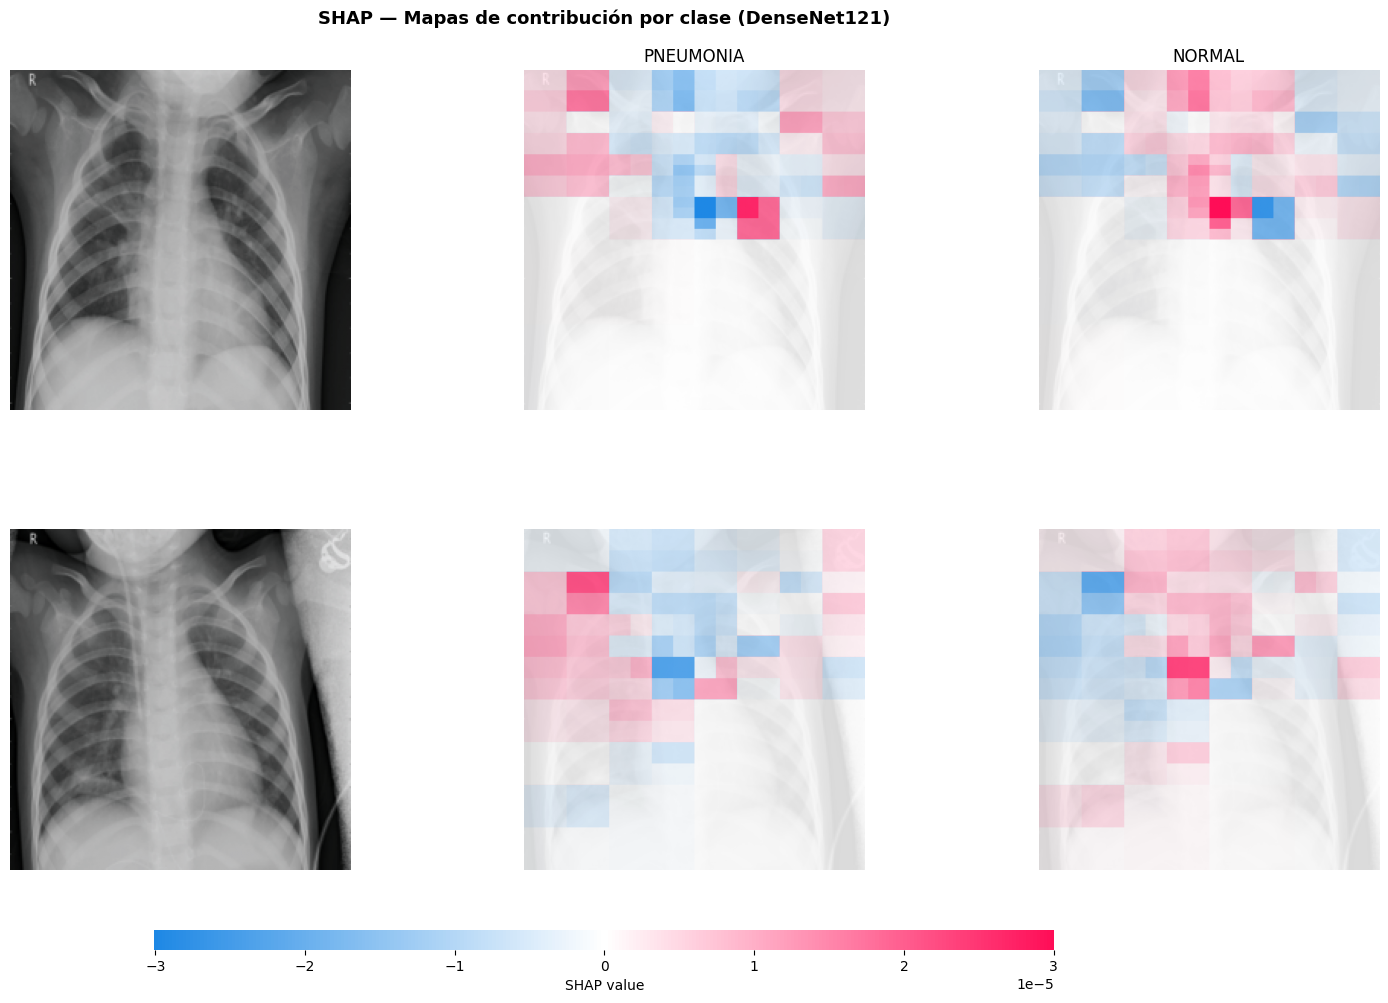

SHAP completado.
  Tiempo total: 111.4s
  Tiempo medio por imagen: 55.701s


In [47]:
# ── SHAP: aplicar y visualizar ────────────────────────────────

tiempos_shap = []
imagenes_shap = []
nombres_shap = []

for nombre, info in casos_xai.items():
    idx = info['idx']
    img_orig, _ = cargar_imagen_original(idx)
    imagenes_shap.append(img_orig.astype(np.float64))
    nombres_shap.append(
        f"{info['tipo']} | Real: {clase_nombre[all_labels[idx]]} | "
        f"Pred: {clase_nombre[all_preds[idx]]} | P={all_probs_test[idx]:.3f}"
    )

imagenes_array = np.array(imagenes_shap)

# Calcular SHAP values
print("Calculando SHAP values (puede tardar varios minutos)...")
t0 = time.time()
shap_values = explainer_shap(
    imagenes_array,
    max_evals=500,
    batch_size=50,
    outputs=shap.Explanation.argsort.flip[:2]
)
t1 = time.time()
tiempo_total = t1 - t0
tiempos_shap = [tiempo_total / len(imagenes_shap)] * len(imagenes_shap)

# ── Visualización SHAP ────────────────────────────────────────────────────
n_imgs = len(imagenes_shap)

shap.image_plot(
    shap_values,
    imagenes_array / 255.0,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(18, 5 * n_imgs)

ax_all = fig.get_axes()
n_cols = len(ax_all) // n_imgs

# Etiquetas laterales
for i, (nombre, info) in enumerate(casos_xai.items()):
    idx = info['idx']
    
    ax_all[i * n_cols].set_ylabel(
        f"{info['tipo']}\n"
        f"Real: {clase_nombre[all_labels[idx]]}\n"
        f"Pred: {clase_nombre[all_preds[idx]]}\n"
        f"P={all_probs_test[idx]:.3f}",
        fontsize=9,
        rotation=0,
        labelpad=75,
        va='center'
    )

# Título
fig.suptitle(
    'SHAP — Mapas de contribución por clase (DenseNet121)',
    fontsize=13,
    fontweight='bold',
    y=0.98
)

# Layout general
plt.subplots_adjust(
    left=0.15,
    right=0.95,
    top=0.92,
    bottom=0.12,
    wspace=0.25,
    hspace=0.35
)

# Mover colorbar abajo
cbar_ax = ax_all[-1]
cbar_ax.set_position([0.25, 0.04, 0.5, 0.02])

# Guardar
plt.savefig('xai_05_shap_densenet.png', dpi=150, bbox_inches='tight')
plt.show()

# Registrar tiempos
tiempos_xai['SHAP'] = {
    'media': np.mean(tiempos_shap),
    'min': np.min(tiempos_shap),
    'max': np.max(tiempos_shap),
}

print(f"SHAP completado.")
print(f"  Tiempo total: {tiempo_total:.1f}s")
print(f"  Tiempo medio por imagen: {np.mean(tiempos_shap):.3f}s")

In [ ]:
print("=" * 70)
print("  COMPARATIVA DE TÉCNICAS DE EXPLICABILIDAD")
print("=" * 70)
print(f"  {'Técnica':<20} {'T.medio(s)':>10} {'T.min(s)':>10} {'T.max(s)':>10}")
print("-" * 70)
for tecnica, datos in tiempos_xai.items():
    print(f"  {tecnica:<20} {datos['media']:>10.3f} {datos['min']:>10.3f} {datos['max']:>10.3f}")
print("=" * 70)

  COMPARATIVA DE TÉCNICAS DE EXPLICABILIDAD
  Técnica              T.medio(s)   T.min(s)   T.max(s)
----------------------------------------------------------------------
  Grad-CAM                  0.272      0.188      0.355
  Grad-CAM++                0.153      0.150      0.156
  Guided Grad-CAM           0.280      0.258      0.301
  LIME                     54.062     53.205     54.919
  SHAP                     39.372     39.372     39.372
